In [ ]:
"""
R004_IMLS_OADS__
|
arxiv_200_oads_urls_extraction_performance.ipynb
Created on Thu Feb 26 23:09:19 2026
@author: Lemos
"""

# OADS URL Extraction Performance — 200-Paper Sample

**OADS** = Open Access Data/Software links: URLs that point to a
**Third Party Dataset (TPD)**, **Third Party Software (TPS)**,
**Author-Provided Dataset (APD)**, **Author-Provided Software (APS)**, or a
**Project** page — as opposed to a **General URL (GenURL)**.

This notebook evaluates how well each document format (and combinations of
formats) recovers **just the OADS-labelled URLs**.

For the broader question of *all* labelled ground-truth URLs regardless of
category, see the companion notebook `arxiv_200_all_urls_extraction_performance.ipynb`. 

## What this notebook does

1. **Data Loading** — reads the superset cretaed in `arxiv_200_all_urls_extraction_performance.ipynb`
2. **OADS category distribution** — how many URLs fall into each OADS
   category vs. GenURL
3. **OADS Recall** — bootstrapped, with 95% CIs, across every combination
   of the 6 single-format extractors, **excluding GenURL**
4. **Significance testing** — Friedman test followed by Wilcoxon
   signed-rank + Holm–Bonferroni (vs. the best single-format baseline)
5. **Characteristic failure modes** — which paper sections / complexity
   types tend to get missed, broken down by format

## Data layout


```
data/200_sample/
├── arxiv_urls_1992_2024_gt.csv                 # REQUIRED: human-labelled ground truth
└── analysis/                                    # generated by this notebook
    ├── arxiv_labelled_urls_merged.csv
    ├── arxiv_extracted_unique_urls_all_200_superset.json # REQUIRED: output from arxiv_200_all_urls_extraction_performance.ipynb 
    ├── oads_63_combos.csv
    ├── friedman_oads_recall.csv
    └── significance_oads_recall_holm.csv

results/                                          # generated figures (PDF)
```

## A note on the ground-truth `oads` key

This notebook needs `paper_data['oads']['oads_info']` — a list of
`{url, oads_label}` entries per paper, where `oads_label` is one of
`GenURL`, `TPD`, `TPS`, `APD`, `APS`, `Project`. **This key is assumed to
already exist in the superset JSON**.

## 1. Data Loading

### 1.1 Paths

In [2]:
import json
from pathlib import Path

DATA_DIR      = Path("data/200_sample")
RESULTS_DIR   = Path("results")
ANALYSIS_DIR  = DATA_DIR / "analysis"
LABELS = DATA_DIR / "arxiv_urls_1992_2024_gt.csv"
SUPERSET_JSON   = ANALYSIS_DIR / "arxiv_extracted_unique_urls_all_200_superset.json"

for d in [ANALYSIS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SINGLE_FORMATS = ["textwal_pymupdf", "latex", "html", "xml", "vlm_qwen", "markdown"]

FORMAT_LABELS = {
    "textwal_pymupdf":  "TEXTWAL",
    "latex":    "LaTeX",
    "html":     "HTML",
    "xml":      "XML",
    "vlm_qwen": "Qwen2-VL",
    "markdown": "Markdown",
}

### 1.2 Read the human-labelled ground truth

In [3]:
import pandas as pd

df_labels = pd.read_csv(LABELS, dtype={"arxiv_id": str})
print(f"Rows before de-duplication : {len(df_labels)}")

df_labels_u = df_labels.drop_duplicates(subset=['arxiv_id', 'URL'], keep='first')
print(f"Rows after de-duplication  : {len(df_labels_u)}")

Rows before de-duplication : 2420
Rows after de-duplication  : 2338


In [4]:
with open(SUPERSET_JSON, 'r', encoding='utf-8') as f:
    arxiv_all_200 = json.load(f)

print(f"Papers in extraction JSON: {len(arxiv_all_200)}")

n_with_oads = sum(1 for v in arxiv_all_200.values() if 'oads' in v and v['oads'].get('oads_info'))
print(f"Papers with an 'oads' key already attached: {n_with_oads}")

Papers in extraction JSON: 200
Papers with an 'oads' key already attached: 190


### 1.4 Shared helper

Used throughout the rest of this notebook to get the union of URLs
extracted by a given set of formats for one paper.

In [5]:
def get_extracted_urls(paper_data: dict, formats) -> set:
    """Union of extracted URLs across all formats in `formats` for one paper."""
    urls = set()
    for fmt in formats:
        fmt_data = paper_data.get(fmt, {})
        if 'url_info' in fmt_data:
            urls.update(x['url'] for x in fmt_data['url_info'])
        elif 'urls' in fmt_data:
            urls.update(fmt_data['urls'] or [])
    return urls

## 2. OADS category distribution

How many ground-truth URLs fall into each OADS category, computed directly
from the attached `oads_info`.

In [5]:
%matplotlib inline
from collections import Counter
import matplotlib.pyplot as plt

oads_counter = Counter()
for paper_data in arxiv_all_200.values():
    if 'oads' not in paper_data:
        continue
    for entry in paper_data['oads'].get('oads_info', []):
        label = entry.get('oads_label')
        if label:
            oads_counter[label] += 1

print("OADS label counts:")
for label, count in oads_counter.most_common():
    print(f"  {label:<10} {count}")

total = sum(oads_counter.values())
non_genurl = total - oads_counter.get('GenURL', 0)
print(f"\nTotal labelled URLs      : {total}")
print(f"Non-GenURL (OADS) URLs   : {non_genurl}  ({non_genurl / total:.1%} of all labelled URLs)")

OADS label counts:
  GenURL     1850
  TPS        207
  TPD        146
  Project    100
  APD        19
  APS        16

Total labelled URLs      : 2338
Non-GenURL (OADS) URLs   : 488  (20.9% of all labelled URLs)


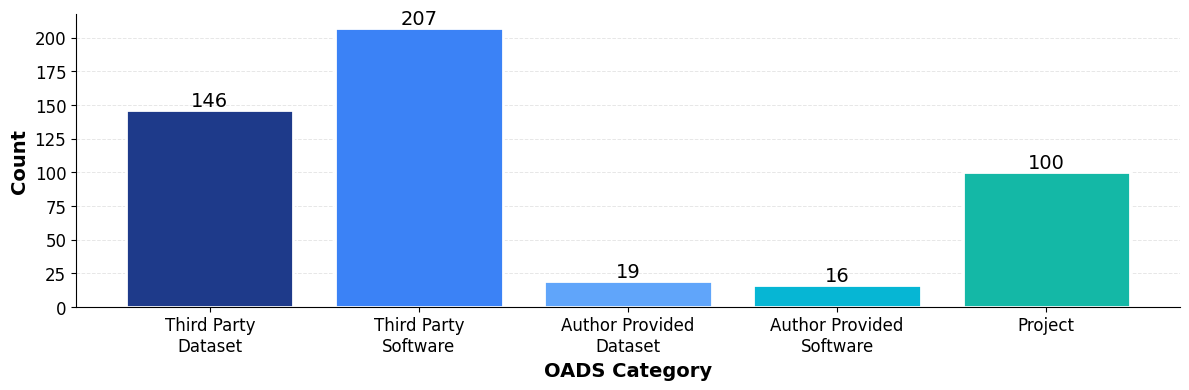

In [6]:
category_names = {
    'TPD': 'Third Party\nDataset', 'TPS': 'Third Party\nSoftware',
    'APD': 'Author Provided\nDataset', 'APS': 'Author Provided\nSoftware',
    'Project': 'Project', 'GenURL': 'General URL',
}
colors = ['#1e3a8a', '#3b82f6', '#60a5fa', '#06b6d4', '#14b8a6', '#10b981']

# Non-GenURL categories only, in a fixed order
oads_only_order = ['TPD', 'TPS', 'APD', 'APS', 'Project']
labels = [category_names[k] for k in oads_only_order]
values = [oads_counter.get(k, 0) for k in oads_only_order]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(labels, values, color=colors[:len(labels)], edgecolor='white', linewidth=2)

ax.set_ylabel('Count', fontsize=14, fontweight='bold')
ax.set_xlabel('OADS Category', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height, f'{int(height)}',
            ha='center', va='bottom', fontsize=14)

plt.xticks(rotation=0, ha='center', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'oads_distribution.pdf', format='pdf')
plt.show()

## 3. OADS Recall across all 63 format combinations

Bootstrapped (B=10,000 resamples over the 200 papers) Recall for every
non-empty combination of the 6 single formats, against the OADS-labelled
ground truth **excluding GenURL** — i.e. does this format (combination)
find the dataset/software/project links specifically?

In [9]:
import numpy as np
from itertools import combinations

all_combos = []
for r in range(1, len(SINGLE_FORMATS) + 1):
    all_combos.extend(combinations(SINGLE_FORMATS, r))

# --- Precompute per-paper OADS ground-truth count (excl. GenURL) and per-combo hits ---
gt_per_paper = {}
ext_per_paper = {combo: {} for combo in all_combos}
valid_papers = []

for arxiv_id, paper_data in arxiv_all_200.items():
    if 'oads' not in paper_data:
        continue
    oads_info = paper_data['oads'].get('oads_info', [])
    if not oads_info:
        continue

    gt_urls = {x['url'] for x in oads_info if x.get('oads_label') != 'GenURL'}
    valid_papers.append(arxiv_id)
    gt_per_paper[arxiv_id] = len(gt_urls)

    for combo in all_combos:
        extracted = get_extracted_urls(paper_data, combo)
        ext_per_paper[combo][arxiv_id] = sum(1 for url in gt_urls if url in extracted)

gt_arr = np.array([gt_per_paper[p] for p in valid_papers])
ext_arrs = {c: np.array([ext_per_paper[c][p] for p in valid_papers]) for c in all_combos}

print(f"Papers with OADS ground-truth URLs : {len(valid_papers)}")
print(f"Total non-GenURL OADS URLs         : {gt_arr.sum()}")

Papers with OADS ground-truth URLs : 190
Total non-GenURL OADS URLs         : 488


In [10]:
# --- Bootstrap ---
np.random.seed(42)
n_iterations = 10_000
n_papers = len(valid_papers)
paper_indices = np.arange(n_papers)

bootstrapped_recalls = {combo: [] for combo in all_combos}
for _ in range(n_iterations):
    indices = np.random.choice(paper_indices, size=n_papers, replace=True)
    total_gt = gt_arr[indices].sum()
    for combo in all_combos:
        total_ext = ext_arrs[combo][indices].sum()
        bootstrapped_recalls[combo].append(total_ext / total_gt if total_gt > 0 else 0)

# --- Final point estimates + 95% CIs ---
results = []
actual_gt = gt_arr.sum()
for combo in all_combos:
    label = " + ".join(FORMAT_LABELS[f] for f in combo)
    actual_ext = ext_arrs[combo].sum()
    actual_recall = actual_ext / actual_gt if actual_gt > 0 else 0
    results.append({
        'Format Combination': label,
        'N_Formats': len(combo),
        'OADS_VP': actual_ext,
        'OADS_Total': actual_gt,
        'OADS_R': round(actual_recall, 4),
        'OADS_Missing%': round(100 * (1 - actual_recall), 1),
        'OADS_R_95%_CI_Lower': round(np.percentile(bootstrapped_recalls[combo], 2.5), 4),
        'OADS_R_95%_CI_Upper': round(np.percentile(bootstrapped_recalls[combo], 97.5), 4),
    })

df_combos = pd.DataFrame(results).sort_values(by=['N_Formats', 'OADS_R'], ascending=[True, False])
df_combos.to_csv(ANALYSIS_DIR / "oads_63_combos.csv", index=False)
print(f"Saved -> {ANALYSIS_DIR / 'oads_63_combos.csv'}")

Saved -> data/200_sample/analysis/oads_63_combos.csv


### 3.1 Plot: OADS Recall across all 63 combinations

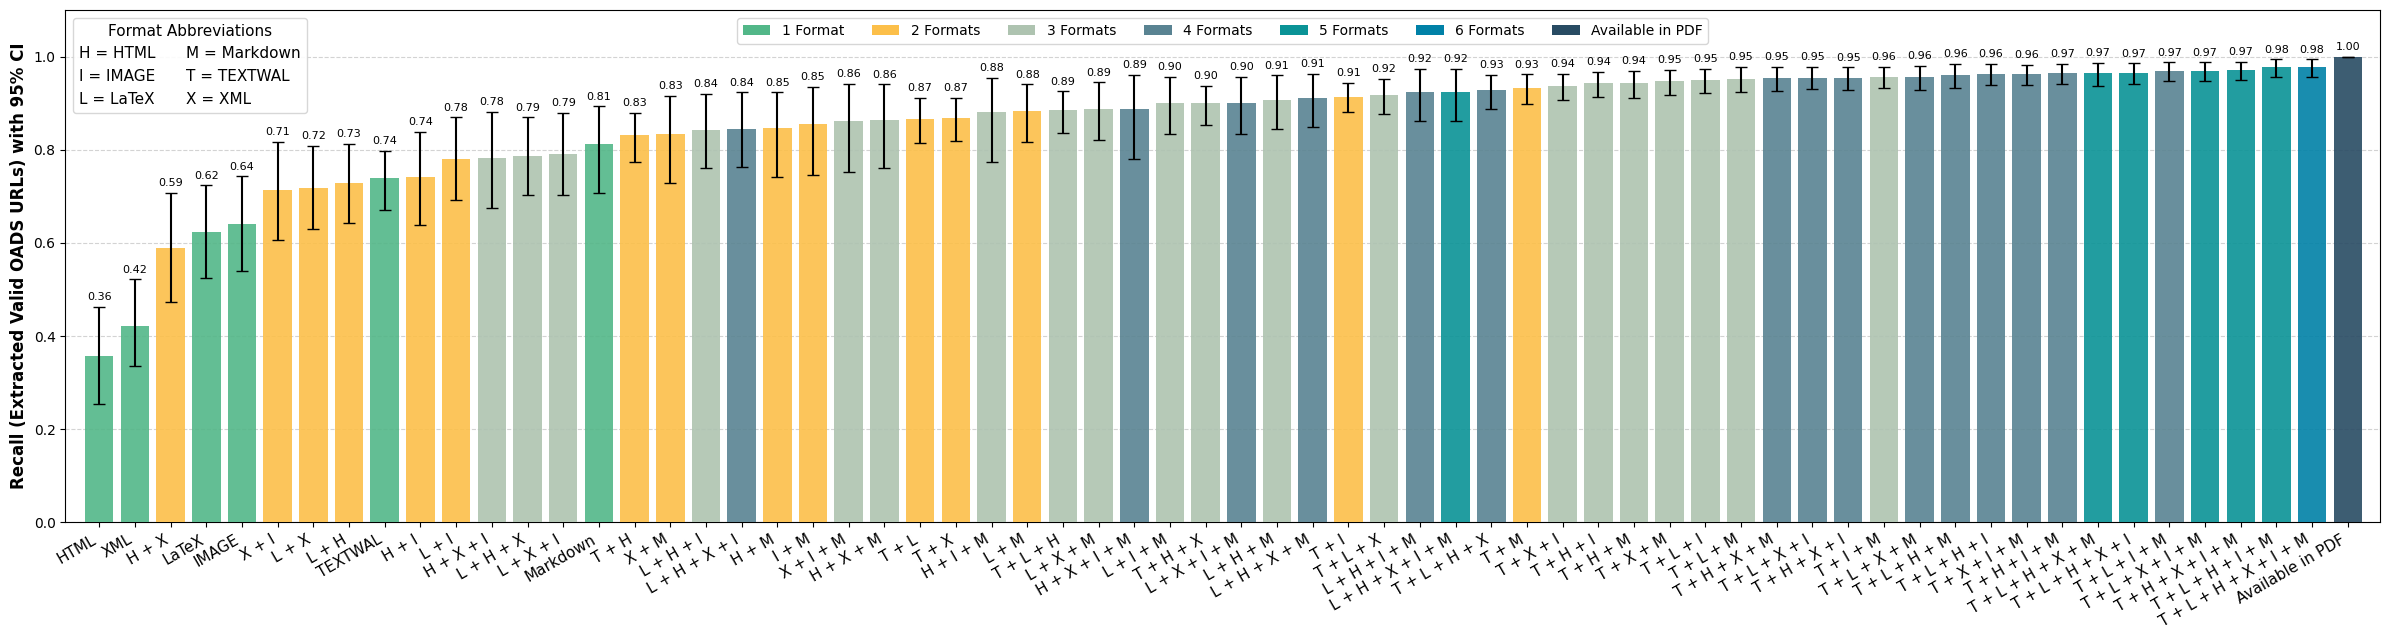

In [16]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# Create directory
os.makedirs('results', exist_ok=True)

df = df_combos.copy()

df = df.rename(columns={
    'Format Combination': 'label',
    'N_Formats': 'n_formats',
    'OADS_R': 'recall',
    'OADS_R_95%_CI_Lower': 'lower_ci',
    'OADS_R_95%_CI_Upper': 'upper_ci'
})

# Sort by recall
df = df.sort_values('recall')

# --- Dynamic Abbreviations & Label Formatting ---
# Dynamically find unique formats to build the abbreviation map
unique_formats = set()
for label in df['label']:
    if '+' in label:
        unique_formats.update([f.strip() for f in label.split('+')])
    elif ',' in label:
        unique_formats.update([f.strip() for f in label.split(',')])
    else:
        unique_formats.add(label.strip())

# Build the abbreviation mapping for the top-left legend
abbr_mapping = {}
for f in unique_formats:
    if f == 'Qwen2-VL':
        abbr_mapping['I'] = 'IMAGE'
    else:
        abbr_mapping[f[0].upper()] = f

# Function to apply the requested label formatting rules
def format_x_label(label):
    # Determine separator and extract parts
    if '+' in label:
        parts = [p.strip() for p in label.split('+')]
    elif ',' in label:
        parts = [p.strip() for p in label.split(',')]
    else:
        parts = [label.strip()]

    # Single format scenario
    if len(parts) == 1:
        return 'IMAGE' if parts[0] == 'Qwen2-VL' else parts[0]

    # Multiple format scenario
    abbrs = ['I' if p == 'Qwen2-VL' else p[0].upper() for p in parts]
    return ' + '.join(abbrs)

# Prepare plot data
labels = [format_x_label(lbl) for lbl in df['label'].tolist()]
recalls = df['recall'].tolist()
n_formats_list = df['n_formats'].tolist()

# Error bars (relative to mean)
lower_err = [r - l for r, l in zip(recalls, df['lower_ci'])]
upper_err = [u - r for u, r in zip(df['upper_ci'], recalls)]

labels.append('Available in PDF')
recalls.append(1.0)
n_formats_list.append('gt') 
lower_err.append(0.0)
upper_err.append(0.0)

# Plotting with updated color palette
color_palette = {
    1: "#52b788", # (1 Format)
    2: "#fcbf49", # (2 Formats)
    3: "#aec3b0", # (3 Formats)
    4: "#598392", # (4 Formats)
    5: "#0a9396", # (5 Formats)
    6: "#0081a7", # (6 Formats)
    'gt': "#284b63" # (Available in PDF)
}

colors = [color_palette[n] for n in n_formats_list]

plt.figure(figsize=(24, 6.5))
bars = plt.bar(labels, recalls, color=colors, yerr=[lower_err, upper_err], capsize=4, zorder=3, alpha=0.9)

ax = plt.gca()
ax.margins(x=0)
ax.set_xlim(-0.95, len(labels)-0.1)

# Annotate bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    y_pos = recalls[i] + upper_err[i] + 0.01
    plt.text(bar.get_x() + bar.get_width() / 2, y_pos, f"{height:.2f}", 
             ha="center", va="bottom", fontsize=8, rotation=0)

plt.xticks(rotation=30, ha="right", fontsize=11)

plt.ylabel("Recall (Extracted Valid OADS URLs) with 95% CI",fontsize=12, fontweight="bold")
plt.ylim(0, 1.1)
plt.grid(axis="y", linestyle="dashed", color="lightgray", zorder=0)

# --- MAIN LEGEND ---
legend_elements = [
    Patch(facecolor=color_palette[1], label="1 Format"),
    Patch(facecolor=color_palette[2], label="2 Formats"),
    Patch(facecolor=color_palette[3], label="3 Formats"),
    Patch(facecolor=color_palette[4], label="4 Formats"),
    Patch(facecolor=color_palette[5], label="5 Formats"),
    Patch(facecolor=color_palette[6], label="6 Formats"),
    Patch(facecolor=color_palette['gt'], label="Available in PDF"),
]

main_legend = plt.legend(handles=legend_elements, ncol=7, loc="upper center", bbox_to_anchor=(0.5, 0.997),fontsize=10)
ax.add_artist(main_legend) 

# --- ABBREVIATION LEGEND ---
abbr_handles = [Patch(color='none', label=f"{k} = {v}") for k, v in sorted(abbr_mapping.items())]
plt.legend(handles=abbr_handles, loc="upper left", title="Format Abbreviations", 
           handlelength=0, handletextpad=0, fontsize=11, title_fontsize=11,
           framealpha=0.9, edgecolor="lightgray", ncol=2, columnspacing=2.0)

plt.tight_layout()
plt.savefig('results/all_valid_OADS_urls_recall_63_combinations.pdf', format='pdf')
plt.show()

## 4. Friedman test — is there a global difference across the 6 formats?

In [12]:
from scipy.stats import friedmanchisquare

rows = []
for arxiv_id, paper_data in arxiv_all_200.items():
    if 'oads' not in paper_data:
        continue
    oads_info = paper_data['oads'].get('oads_info', [])
    gt_urls = {x['url'] for x in oads_info if x.get('oads_label') != 'GenURL'}
    if not gt_urls:
        continue
    row = {'arxiv_id': arxiv_id}
    for fmt in SINGLE_FORMATS:
        extracted = get_extracted_urls(paper_data, (fmt,))
        row[fmt] = len(gt_urls & extracted) / len(gt_urls)
    rows.append(row)

df_scores = pd.DataFrame(rows)
matrix = df_scores[SINGLE_FORMATS].copy()
matrix.columns = [FORMAT_LABELS[f] for f in SINGLE_FORMATS]
print(f"Papers with OADS ground-truth URLs: {len(matrix)}")

stat, p = friedmanchisquare(*[matrix[col].values for col in matrix.columns])
df_stat = matrix.shape[1] - 1
mean_ranks = matrix.rank(axis=1).mean(axis=0).sort_values(ascending=False)

print(f"\nFriedman Test — OADS Recall")
print(f"N papers  : {len(matrix)}")
print(f"k formats : {matrix.shape[1]}  ({', '.join(matrix.columns)})")
print(f"chi2({df_stat}) : {stat:.4f}")
print(f"p-value   : {p:.4e}")
sig = ("*** p < 0.001" if p < 0.001 else "**  p < 0.01" if p < 0.01 else
       "*   p < 0.05" if p < 0.05 else "ns  p >= 0.05")
print(f"Result    : {sig} -> {'at least one format differs' if p < 0.05 else 'no significant global difference'}")
print("\nMean within-paper ranks (higher = better):")
for label, mr in mean_ranks.items():
    print(f"  {label:<12} {mr:.3f}")

pd.DataFrame([{
    'metric': 'OADS Recall', 'n_papers': len(matrix), 'k_formats': matrix.shape[1],
    'chi2': round(stat, 4), 'df': df_stat, 'p_value': p, 'significant': p < 0.05,
}]).to_csv(ANALYSIS_DIR / "friedman_oads_recall.csv", index=False)

Papers with OADS ground-truth URLs: 122

Friedman Test — OADS Recall
N papers  : 122
k formats : 6  (TEXTWAL, LaTeX, HTML, XML, Qwen2-VL, Markdown)
chi2(5) : 129.2918
p-value   : 3.3639e-26
Result    : *** p < 0.001 -> at least one format differs

Mean within-paper ranks (higher = better):
  Markdown     4.520
  Qwen2-VL     3.840
  TEXTWAL      3.689
  LaTeX        3.545
  XML          2.996
  HTML         2.410


## 5. Wilcoxon signed-rank test + Holm–Bonferroni correction

Compares every one of the other 62 format combinations against the best
single-format baseline (`Markdown`, by OADS Recall) on a per-paper basis,
with Holm–Bonferroni correction for multiple comparisons and rank-biserial
correlation as the effect size.

Requires `statsmodels` (`pip install statsmodels`).

In [13]:
from scipy.stats import wilcoxon, rankdata
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

baseline_combo = ('markdown',)  # highest single-format OADS Recall
print(f"Baseline: {baseline_combo}")

def compute_rank_biserial(x, y):
    """Rank-biserial correlation effect size for paired samples (-1..1);
    positive means x outperforms baseline y."""
    diff = x - y
    diff = diff[diff != 0]
    if len(diff) == 0:
        return 0.0
    abs_ranks = rankdata(np.abs(diff))
    pos = abs_ranks[diff > 0].sum()
    neg = abs_ranks[diff < 0].sum()
    return (pos - neg) / abs_ranks.sum()

doc_level_r = {combo: [] for combo in all_combos}
doc_papers = []
for arxiv_id, paper_data in arxiv_all_200.items():
    if 'oads' not in paper_data:
        continue
    oads_info = paper_data['oads'].get('oads_info', [])
    gt_urls = {x['url'] for x in oads_info if x.get('oads_label') != 'GenURL'}
    if not gt_urls:
        continue
    doc_papers.append(arxiv_id)
    for combo in all_combos:
        extracted = get_extracted_urls(paper_data, combo)
        doc_level_r[combo].append(len(gt_urls & extracted) / len(gt_urls))

for combo in all_combos:
    doc_level_r[combo] = np.array(doc_level_r[combo])

baseline_arr = doc_level_r[baseline_combo]
print(f"Papers used: {len(doc_papers)}")

test_combos = [c for c in all_combos if c != baseline_combo]
raw_p, effects = {}, {}
for combo in test_combos:
    stat, p = wilcoxon(doc_level_r[combo], baseline_arr, mode='approx')
    raw_p[combo] = p
    effects[combo] = compute_rank_biserial(doc_level_r[combo], baseline_arr)

reject, pvals_corrected, _, _ = multipletests(list(raw_p.values()), alpha=0.05, method='holm')
sig = {c: (pvals_corrected[i], bool(reject[i]), effects[c]) for i, c in enumerate(raw_p)}

final_results = []
for combo in all_combos:
    label = " + ".join(combo)
    if combo == baseline_combo:
        final_results.append({'Combination': label, 'Baseline': " + ".join(baseline_combo),
                               'Holm_p': np.nan, 'Significant': np.nan, 'Effect_Size': np.nan,
                               'Note': 'BASELINE'})
    else:
        p_val, is_sig, eff = sig[combo]
        final_results.append({'Combination': label, 'Baseline': " + ".join(baseline_combo),
                               'Holm_p': p_val, 'Significant': is_sig, 'Effect_Size': eff, 'Note': ''})

df_sig = pd.DataFrame(final_results)
df_sig.to_csv(ANALYSIS_DIR / "significance_oads_recall_holm.csv", index=False)
print(f"\nSaved -> {ANALYSIS_DIR / 'significance_oads_recall_holm.csv'}")
print(f"Rows: {len(df_sig)}")
df_sig.sort_values('Holm_p').head(10)

Baseline: ('markdown',)
Papers used: 122

Saved -> data/200_sample/analysis/significance_oads_recall_holm.csv
Rows: 63


,Combination,Baseline,Holm_p,Significant,Effect_Size,Note
2,html,markdown,3.852281e-14,True,-0.953358,
3,xml,markdown,1.273064e-09,True,-0.867251,
1,latex,markdown,8.792178e-06,True,-0.747115,
15,html + xml,markdown,2.594448e-05,True,-0.726687,
62,textwal_pymupdf + latex + html + xml + vlm_qwe...,markdown,4.407511e-05,True,1.000000,
58,textwal_pymupdf + latex + html + vlm_qwen + ma...,markdown,4.407511e-05,True,1.000000,
59,textwal_pymupdf + latex + xml + vlm_qwen + mar...,markdown,6.264179e-05,True,1.000000,
46,textwal_pymupdf + latex + vlm_qwen + markdown,markdown,6.264179e-05,True,1.000000,
60,textwal_pymupdf + html + xml + vlm_qwen + mark...,markdown,8.932400e-05,True,1.000000,
49,textwal_pymupdf + html + vlm_qwen + markdown,markdown,1.291248e-04,True,1.000000,


## 6. Characteristic failure modes

For OADS URLs specifically (excluding GenURL), which paper sections and
which complexity types (lexicographical / spatial / representational) tend
to get missed, broken down by format?

In [6]:
import json
import pandas as pd
from collections import Counter

formats_to_evaluate = ["textwal_pymupdf", "html", "xml", "latex", "markdown", "vlm_qwen"]

df = df_labels.copy()
df_cleaned = df.drop_duplicates(subset=['arxiv_id', 'URL'], keep='first')

# Build a lookup dictionary for ground truth metadata
gt_metadata = {}
for _, row in df_cleaned.iterrows():
    a_id = str(row['arxiv_id']).strip()
    url = str(row['URL']).strip()
    gt_metadata[(a_id, url)] = {
        'location': str(row.get('location', 'Unknown')),
        'lexicographical': str(row.get('Lexicographical Complexity', 'None')),
        'spatial': str(row.get('Spatial Complexity', 'None')),
        'representational': str(row.get('Representational Complexity', 'None'))
    }

paper_data_dict = arxiv_all_200.copy()

def get_extracted_urls(paper_data, fmt):
    urls = set()
    if fmt in paper_data:
        if 'url_info' in paper_data[fmt]:
            urls.update([x['url'].strip() for x in paper_data[fmt]['url_info']])
        elif 'urls' in paper_data[fmt]:
            urls.update([str(x).strip() for x in paper_data[fmt]['urls']])
    return urls

# ── Initialize Trackers ───────────────────────────────────────────────────

# Tracker for Global Ground Truth occurrences
gt_stats = {
    'location': Counter(),
    'lexicographical': Counter(),
    'spatial': Counter(),
    'representational': Counter()
}

# Tracker for Missed URLs by format
missed_stats = {fmt: {
    'location': Counter(),
    'lexicographical': Counter(),
    'spatial': Counter(),
    'representational': Counter()
} for fmt in formats_to_evaluate}

# ── Process Data and Find False Negatives ─────────────────────────────────
for arxiv_id, paper_data in paper_data_dict.items():
    if 'oads' not in paper_data:
        continue
    oads_info = paper_data['oads'].get('oads_info', [])
    if not oads_info:
        continue

    # Pre-fetch all extracted URLs by format for this document
    extracted_by_fmt = {fmt: get_extracted_urls(paper_data, fmt) for fmt in formats_to_evaluate}

    for item in oads_info:
        # # Exclude GenURL if you only want to analyze complex OADS URLs
        if item.get('oads_label') == 'GenURL':
            continue 
            
        gt_url = str(item['url']).strip()
        
        # Look up metadata in CSV map
        meta = gt_metadata.get((str(arxiv_id), gt_url))
        if not meta:
            continue

        # --- Tally Ground Truth Characteristics (Do this exactly once per URL) ---
        loc = meta['location']
        if loc.lower() != 'nan': 
            gt_stats['location'][loc] += 1
        
        lex = meta['lexicographical']
        if lex.lower() != 'nan': 
            for l in lex.split(','):
                gt_stats['lexicographical'][l.strip()] += 1
        
        spat = meta['spatial']
        if spat.lower() != 'nan': 
            for s in spat.split(','):
                gt_stats['spatial'][s.strip()] += 1
        
        rep = meta['representational']
        if rep.lower() != 'nan': 
            for r in rep.split(','):
                gt_stats['representational'][r.strip()] += 1

        # --- Check which formats MISSED this URL ---
        for fmt in formats_to_evaluate:
            if gt_url not in extracted_by_fmt[fmt]:
                # This is a MISSED URL. Tally its characteristics for this specific format.
                if loc.lower() != 'nan': 
                    missed_stats[fmt]['location'][loc] += 1
                
                if lex.lower() != 'nan': 
                    for l in lex.split(','):
                        missed_stats[fmt]['lexicographical'][l.strip()] += 1
                
                if spat.lower() != 'nan': 
                    for s in spat.split(','):
                        missed_stats[fmt]['spatial'][s.strip()] += 1
                
                if rep.lower() != 'nan': 
                    for r in rep.split(','):
                        missed_stats[fmt]['representational'][r.strip()] += 1


print("=== CHARACTERISTIC FAILURE MODES BY FORMAT (PERCENTAGES) ===")

categories = {
    'location': 'Regions (Location)',
    'spatial': 'Spatial Complexities',
    'lexicographical': 'Lexicographical Complexities',
    'representational': 'Representational Complexities'
}

for fmt in formats_to_evaluate:
    print(f"--- Format: {fmt.upper()} ---")
    
    for cat_key, cat_name in categories.items():
        print(f"  Most Missed {cat_name}:")
        
        # If this format missed nothing in this category, skip
        if sum(missed_stats[fmt][cat_key].values()) == 0:
            print("    - No misses recorded")
            continue
            
        # Iterate over the highest missed categories
        for val, count in missed_stats[fmt][cat_key].most_common(8):
            
            # The denominator is the TOTAL number of times this characteristic appeared in the ground truth
            total_gt_occurrences = gt_stats[cat_key][val]
            
            if total_gt_occurrences > 0:
                pct = (count / total_gt_occurrences) * 100
            else:
                pct = 0.0
            
            print(f"    - {val}: {pct:.1f}% ({count} missed out of {total_gt_occurrences} GT URLs)")
            
    print("\n")

=== CHARACTERISTIC FAILURE MODES BY FORMAT (PERCENTAGES) ===
--- Format: TEXTWAL_PYMUPDF ---
  Most Missed Regions (Location):
    - References: 23.8% (60 missed out of 252 GT URLs)
    - Methodology: 21.1% (28 missed out of 133 GT URLs)
    - Results and Discussion: 38.6% (22 missed out of 57 GT URLs)
    - Related Works & Background: 46.2% (6 missed out of 13 GT URLs)
    - Introduction: 33.3% (4 missed out of 12 GT URLs)
    - Conclusions: 23.1% (3 missed out of 13 GT URLs)
    - Title & Authors: 100.0% (1 missed out of 1 GT URLs)
  Most Missed Spatial Complexities:
    - embedded in references: 23.4% (54 missed out of 231 GT URLs)
    - embedded in footnotes: 27.3% (45 missed out of 165 GT URLs)
    - split across lines: 27.6% (24 missed out of 87 GT URLs)
    - split across pages: 25.0% (1 missed out of 4 GT URLs)
    - embedded in captions: 50.0% (1 missed out of 2 GT URLs)
  Most Missed Lexicographical Complexities:
    - "URLs with schemes such as http: 25.6% (119 missed out of